In [40]:
# Spillover-Gated Carry Trade
# Long EM / short HAVEN, position sized continuously by spillover level
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from statsmodels.tsa.api import VAR
from retrieve.get_data import get_yield

In [41]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
term     = 5

raw_yields    = get_yield(term, freq="W-FRI") / 100
yield_changes = raw_yields.diff().dropna()
carry         = raw_yields.shift(1).reindex(yield_changes.index) / 52
bond_rets     = carry - term * yield_changes

print(f"Date range: {yield_changes.index.min().date()} to {yield_changes.index.max().date()} ({len(yield_changes)} weeks)")

Date range: 2012-02-03 to 2026-03-13 (737 weeks)


In [62]:
# ── 2. SETTINGS ───────────────────────────────────────────────────────────────
EM_BASKET    = ['INDO', 'BRAZIL', 'MEXICO', 'INDIA']
HAVEN_BASKET = ['US', 'GER', 'JAPAN', 'SWITZ']

SPILL_WINDOW  = 104
VAR_LAGS      = 1
FEVD_H        = 10
REGIME_WINDOW = 104
LOOKBACK      = 104

STARTING_CASH  = 100_000.0
TCOST_BPS      = 0
INCLUDE_BORROW = False   # True = deduct borrowing cost when scalar > 1x

# ── DATE RANGE ────────────────────────────────────────────────────────────────
START_DATE =  '2022-01-01'  # backtest + analysis start (None = use first available)
END_DATE   =  None  # backtest + analysis end   (None = use last available)


In [43]:
# ── 3. HELPERS ────────────────────────────────────────────────────────────────
def generalized_fevd(var_results, H=10, normalize=True):
    names      = list(var_results.names)
    n          = len(names)
    Psi        = var_results.ma_rep(H)
    Sigma      = np.asarray(var_results.sigma_u)
    sigma_diag = np.diag(Sigma).copy()
    fevd       = np.zeros((H, n, n), dtype=float)
    cum_numer  = np.zeros((n, n), dtype=float)
    cum_denom  = np.zeros(n, dtype=float)
    for h in range(H):
        A = Psi[h] @ Sigma
        cum_denom += np.diag(A @ Psi[h].T)
        cum_numer += (A ** 2)
        fevd[h] = (cum_numer / sigma_diag) / cum_denom[:, None]
        if normalize:
            fevd[h] /= fevd[h].sum(axis=1, keepdims=True)
    return fevd, names

def total_spillover(var_results, H=10):
    fevd, names = generalized_fevd(var_results, H=H, normalize=True)
    theta = fevd[-1]
    return (theta.sum() - np.trace(theta)) / theta.shape[0] * 100

def tangency_weights(mu, Sigma):
    n  = len(mu)
    w0 = np.ones(n) / n
    def neg_sharpe(w):
        ret = float(w @ mu)
        vol = np.sqrt(max(float(w @ Sigma @ w), 1e-24))
        return -ret / vol
    res = minimize(neg_sharpe, w0, method="SLSQP",
                   bounds=[(0.0, 1.0)] * n,
                   constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
                   options={"ftol": 1e-12, "maxiter": 500})
    return res.x if res.success else w0

In [63]:
# ── 4. ROLLING SPILLOVER INDEX ────────────────────────────────────────────────
dates        = yield_changes.index
spill_series = {}

for i in range(SPILL_WINDOW, len(dates)):
    window = yield_changes.iloc[i - SPILL_WINDOW : i]
    window = window.replace([np.inf, -np.inf], np.nan).dropna()
    if len(window) < SPILL_WINDOW * 0.8:
        continue
    try:
        res = VAR(window).fit(VAR_LAGS)
        spill_series[dates[i]] = total_spillover(res, H=FEVD_H)
    except Exception:
        continue

spill = pd.Series(spill_series, name="spillover")
print(f"Spillover: {len(spill)} weeks  {spill.index.min().date()} to {spill.index.max().date()}")
print(spill.describe().round(2))
spread_ret = bond_rets[EM_BASKET].mean(axis=1) - bond_rets[HAVEN_BASKET].mean(axis=1)


Spillover: 633 weeks  2014-01-31 to 2026-03-13
count    633.00
mean      58.19
std        6.20
min       47.07
25%       52.67
50%       56.75
75%       64.16
max       68.60
Name: spillover, dtype: float64


In [64]:
# ── 5. POSITION SCALAR ────────────────────────────────────────────────────────
# Binary: 1x when spillover below rolling median, 0x (cash) when above
Z_WINDOW = 52

roll_median = spill.rolling(Z_WINDOW, min_periods=Z_WINDOW//2).median().shift(1)

position_scalar = pd.Series(np.where(spill < roll_median, 1.0, 0.0),
                             index=spill.index)
position_scalar[roll_median.isna()] = np.nan
position_scalar = position_scalar.dropna()

print(f'Rolling {Z_WINDOW}w median scalar distribution:')
print(position_scalar.value_counts().sort_index())
print(f'Fraction of weeks in trade (1x): {(position_scalar==1.0).mean():.1%}')
print(f'Fraction of weeks in cash (0x):  {(position_scalar==0.0).mean():.1%}')


Rolling 52w median scalar distribution:
0.0    335
1.0    272
Name: count, dtype: int64
Fraction of weeks in trade (1x): 44.8%
Fraction of weeks in cash (0x):  55.2%


In [65]:
# ── 6. SPILLOVER CARRY BACKTEST ───────────────────────────────────────────────
# 1x in trade when spillover below median, 0x in cash (rf) when above
start_date = pd.Timestamp(START_DATE) if START_DATE else dates[SPILL_WINDOW + REGIME_WINDOW]
end_date   = pd.Timestamp(END_DATE)   if END_DATE   else dates[-1]

split_date = dates[dates >= start_date][0]
split_i    = dates.get_loc(split_date)
start_i    = max(split_i, SPILL_WINDOW + REGIME_WINDOW)

end_i = dates.get_loc(dates[dates <= end_date][-1])

tcost_frac  = TCOST_BPS / 10_000
pv          = [STARTING_CASH]
pd_         = [dates[start_i]]
scalar_log  = []
prev_scalar = np.nan

for i in range(start_i, min(end_i, len(dates) - 1)):
    today    = dates[i]
    tomorrow = dates[i + 1]
    cur      = pv[-1]

    if today not in position_scalar.index or pd.isna(position_scalar.loc[today]):
        pv.append(cur); pd_.append(tomorrow)
        scalar_log.append(np.nan)
        continue

    scalar = float(position_scalar.loc[today])
    scalar_log.append(scalar)

    if not np.isnan(prev_scalar):
        cur *= (1 - abs(scalar - prev_scalar) * tcost_frac)
    prev_scalar = scalar

    if tomorrow not in bond_rets.index:
        pv.append(cur); pd_.append(tomorrow)
        continue

    r_next  = bond_rets.loc[tomorrow]
    spread  = r_next[EM_BASKET].mean() - r_next[HAVEN_BASKET].mean()
    rf      = raw_yields['US'].loc[today] / 52
    net_ret = scalar * spread + (1 - scalar) * rf

    pv.append(cur * (1 + net_ret))
    pd_.append(tomorrow)

portfolio_rf = pd.Series(pv, index=pd_, name='portfolio_rf')
scalar_ts    = pd.Series(scalar_log, index=pd_[:-1], name='scalar')
print(f'Period: {split_date.date()} to {pd_[-1].date()}')
print(f'Fraction in trade: {pd.Series(scalar_log).dropna().mean():.1%}')


Period: 2022-01-07 to 2026-03-13
Fraction in trade: 56.4%


In [66]:
# ── 7. BENCHMARKS ─────────────────────────────────────────────────────────────
port_ls = pd.Series(np.nan, index=dates)
port_em = pd.Series(np.nan, index=dates)
port_ls.iloc[start_i] = STARTING_CASH
port_em.iloc[start_i] = STARTING_CASH

for i in range(start_i, min(end_i, len(dates) - 1)):
    today     = dates[i]
    next_date = dates[i + 1]
    if next_date not in bond_rets.index:
        continue
    r = bond_rets.loc[next_date]
    port_ls.loc[next_date] = port_ls.loc[today] * (1 + r[EM_BASKET].mean() - r[HAVEN_BASKET].mean())
    port_em.loc[next_date] = port_em.loc[today] * (1 + r[EM_BASKET].mean())

port_ls = port_ls.ffill()
port_em = port_em.ffill()
print('Benchmarks done.')


Benchmarks done.


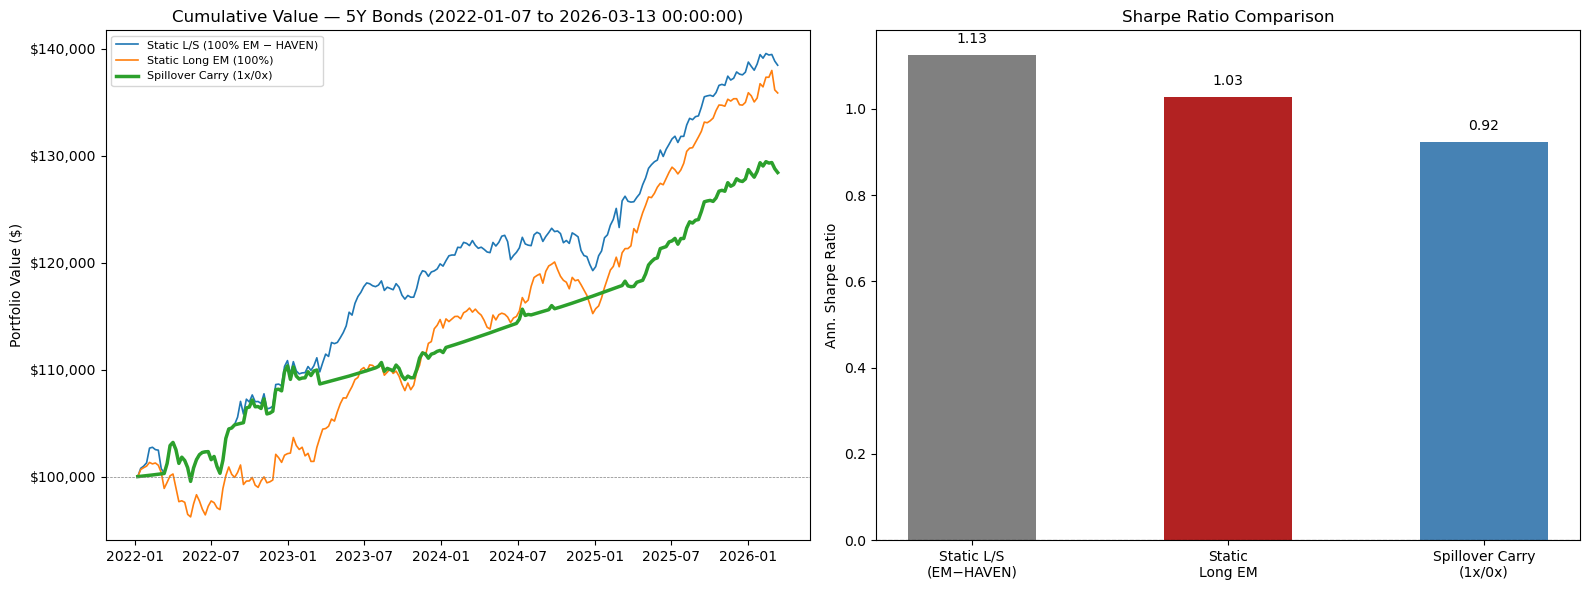

Risk-free rate: 3% p.a. (static)
                        Total Return Ann. Sharpe Ann. Vol Max Drawdown Hit Rate
Strategy                                                                       
Spillover Carry (1x/0x)       28.44%        0.92    3.28%       -3.53%    79.4%
Static L/S (EM−HAVEN)         38.47%        1.13    4.32%       -3.53%    61.5%
Static Long EM                35.88%        1.03    4.29%       -5.03%    61.9%


In [67]:
# ── 8. COMPARISON ─────────────────────────────────────────────────────────────
RF_ANNUAL = 0.03
RF_WEEKLY = RF_ANNUAL / 52

oos_rf = portfolio_rf.loc[split_date:end_date].dropna()
oos_ls = port_ls.loc[split_date:end_date].dropna()
oos_em = port_em.loc[split_date:end_date].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for series, label, color, lw in [
    (oos_ls, 'Static L/S (100% EM − HAVEN)', 'gray',      1.2),
    (oos_em, 'Static Long EM (100%)',         'firebrick', 1.2),
    (oos_rf, 'Spillover Carry (1x/0x)',       'steelblue', 2.5),
]:
    axes[0].plot(series.index, series.values, lw=lw, label=label)

axes[0].axhline(STARTING_CASH, color='gray', ls='--', lw=0.5)
axes[0].set_title(f'Cumulative Value — {term}Y Bonds ({split_date.date()} to {end_date or dates[-1].date()})')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=8)

def ann_sharpe(s):
    wr = s.pct_change().dropna()
    return (wr.mean() - RF_WEEKLY) / wr.std(ddof=0) * np.sqrt(52)

labels  = ['Static L/S\n(EM−HAVEN)', 'Static\nLong EM', 'Spillover Carry\n(1x/0x)']
sharpes = [ann_sharpe(oos_ls), ann_sharpe(oos_em), ann_sharpe(oos_rf)]
colors  = ['gray', 'firebrick', 'steelblue']
bars    = axes[1].bar(labels, sharpes, color=colors, width=0.5)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
for bar, val in zip(bars, sharpes):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02*np.sign(val),
                 f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)
axes[1].set_ylabel('Ann. Sharpe Ratio')
axes[1].set_title('Sharpe Ratio Comparison')
plt.tight_layout()
plt.show()

rows = []
for label, oos in [('Spillover Carry (1x/0x)', oos_rf),
                   ('Static L/S (EM−HAVEN)',    oos_ls),
                   ('Static Long EM',           oos_em)]:
    wr = oos.pct_change().dropna()
    rows.append({'Strategy':     label,
                 'Total Return': f'{oos.iloc[-1]/oos.iloc[0]-1:.2%}',
                 'Ann. Sharpe':  f'{(wr.mean()-RF_WEEKLY)/wr.std(ddof=0)*np.sqrt(52):.2f}',
                 'Ann. Vol':     f'{wr.std(ddof=0)*np.sqrt(52):.2%}',
                 'Max Drawdown': f'{((oos-oos.cummax())/oos.cummax()).min():.2%}',
                 'Hit Rate':     f'{(wr>0).mean():.1%}'})

print(f'Risk-free rate: {RF_ANNUAL:.0%} p.a. (static)')
print(pd.DataFrame(rows).set_index('Strategy').to_string())


                              Definition  N Weeks Ann. Sharpe Ann. Return Ann. Vol
Regime                                                                            
High Spillover  above rolling 52w median       78        0.58       5.60%    4.50%
Low Spillover   below rolling 52w median      141        1.34       8.68%    4.25%


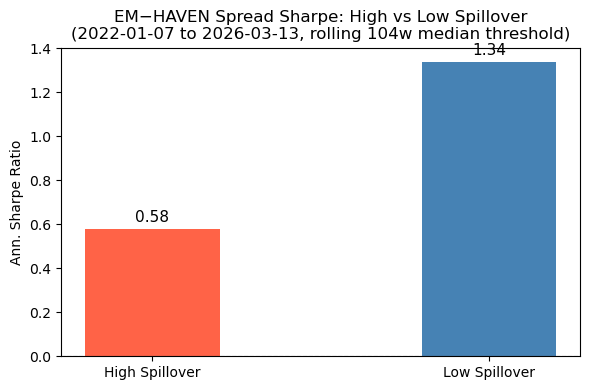

In [68]:
# ── 8b. EM-HAVEN SPREAD SHARPE: HIGH vs LOW SPILLOVER ─────────────────────────
# rolling median threshold (52-week trailing) — no look-ahead bias
rolling_median = spill.rolling(REGIME_WINDOW, min_periods=REGIME_WINDOW//2).median().shift(1)

common = spill.index.intersection(spread_ret.index).intersection(
    rolling_median.dropna().index).intersection(spread_ret.loc[split_date:].index)
spill_aligned  = spill.loc[common]
spread_aligned = spread_ret.loc[common]
threshold      = rolling_median.loc[common]

high_mask = spill_aligned >= threshold
low_mask  = spill_aligned <  threshold

def sharpe(rets, rf_weekly=RF_WEEKLY):
    return (rets.mean() - rf_weekly) / rets.std(ddof=0) * np.sqrt(52)

results = pd.DataFrame({
    "Regime":      ["High Spillover", "Low Spillover"],
    "Definition":  ["above rolling 52w median", "below rolling 52w median"],
    "N Weeks":     [high_mask.sum(), low_mask.sum()],
    "Ann. Sharpe": [f"{sharpe(spread_aligned[high_mask]):.2f}",
                    f"{sharpe(spread_aligned[low_mask]):.2f}"],
    "Ann. Return": [f"{spread_aligned[high_mask].mean()*52:.2%}",
                    f"{spread_aligned[low_mask].mean()*52:.2%}"],
    "Ann. Vol":    [f"{spread_aligned[high_mask].std(ddof=0)*np.sqrt(52):.2%}",
                    f"{spread_aligned[low_mask].std(ddof=0)*np.sqrt(52):.2%}"],
}).set_index("Regime")

print(results.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
sharpe_vals = [sharpe(spread_aligned[high_mask]), sharpe(spread_aligned[low_mask])]
colors = ["tomato", "steelblue"]
bars = ax.bar(["High Spillover", "Low Spillover"], sharpe_vals, color=colors, width=0.4)
ax.axhline(0, color="gray", lw=0.8, ls="--")
for bar, val in zip(bars, sharpe_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02*np.sign(val),
            f"{val:.2f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=11)
ax.set_ylabel("Ann. Sharpe Ratio")
ax.set_title(f"EM−HAVEN Spread Sharpe: High vs Low Spillover\n({split_date.date()} to {end_date.date() if END_DATE else dates[-1].date()}, rolling {REGIME_WINDOW}w median threshold)")
plt.tight_layout()
plt.show()

/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency informatio

                     N Weeks Ann. Return Ann. Vol Ann. Sharpe Hit Rate
Quadrant                                                              
Low Ret / Low Vol        137      10.76%    3.69%        2.10    67.2%
Low Ret / High Vol        87      12.58%    4.51%        2.12    70.1%
High Ret / Low Vol       122       4.90%    3.89%        0.49    58.2%
High Ret / High Vol      175       7.12%    4.61%        0.89    64.0%


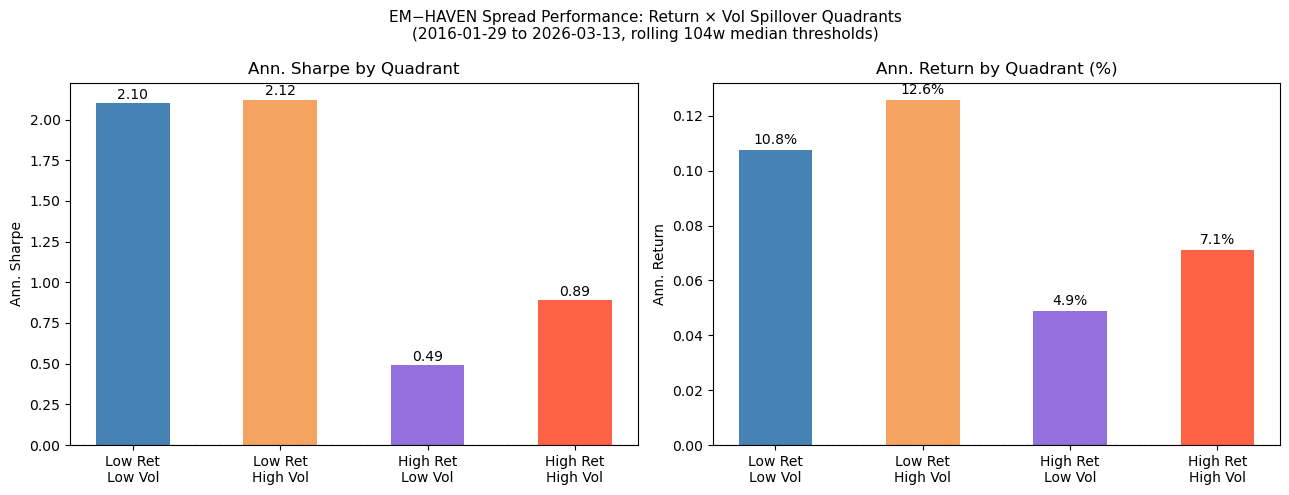

In [54]:
# ── 8c. FOUR-QUADRANT ANALYSIS: RETURN SPILLOVER × VOL SPILLOVER ──────────────

# ── compute rolling vol spillover (log rvol, VAR(3), same window) ─────────────
VAR_LAGS_VOL = 3
raw_d  = get_yield(term, freq='B')
chg_d  = raw_d.diff().dropna()
rvol_w = (chg_d ** 2).resample('W-FRI').sum().apply(np.sqrt)
lvol_w = np.log(rvol_w.replace(0, np.nan)).dropna()

vol_spill_series = {}
vdates = lvol_w.index
for i in range(SPILL_WINDOW, len(vdates)):
    window = lvol_w.iloc[i - SPILL_WINDOW : i].replace([np.inf, -np.inf], np.nan).dropna()
    if len(window) < SPILL_WINDOW * 0.8:
        continue
    try:
        res = VAR(window).fit(VAR_LAGS_VOL)
        vol_spill_series[vdates[i]] = total_spillover(res, H=FEVD_H)
    except Exception:
        continue

spill_vol = pd.Series(vol_spill_series, name="vol_spillover")

# ── rolling medians (lagged 1w, no look-ahead) ────────────────────────────────
ret_med = spill.rolling(REGIME_WINDOW, min_periods=REGIME_WINDOW//2).median().shift(1)
vol_med = spill_vol.rolling(REGIME_WINDOW, min_periods=REGIME_WINDOW//2).median().shift(1)

# ── align everything ──────────────────────────────────────────────────────────
common = (spill.index
          .intersection(spill_vol.index)
          .intersection(ret_med.dropna().index)
          .intersection(vol_med.dropna().index)
          .intersection(spread_ret.index)
          .intersection(spread_ret.loc[split_date:].index))

ret_s  = spill.loc[common]
vol_s  = spill_vol.loc[common]
ret_m  = ret_med.loc[common]
vol_m  = vol_med.loc[common]
spr    = spread_ret.loc[common]

# ── quadrant masks ────────────────────────────────────────────────────────────
ll = (ret_s < ret_m) & (vol_s < vol_m)   # low ret, low vol  → best for carry
lh = (ret_s < ret_m) & (vol_s >= vol_m)  # low ret, high vol
hl = (ret_s >= ret_m) & (vol_s < vol_m)  # high ret, low vol
hh = (ret_s >= ret_m) & (vol_s >= vol_m) # high ret, high vol → worst

def sharpe(rets, rf_weekly=RF_WEEKLY):
    if len(rets) < 2:
        return np.nan
    return (rets.mean() - rf_weekly) / rets.std(ddof=0) * np.sqrt(52)

quadrants = {
    "Low Ret / Low Vol":  ll,
    "Low Ret / High Vol": lh,
    "High Ret / Low Vol": hl,
    "High Ret / High Vol": hh,
}

rows = []
for label, mask in quadrants.items():
    r = spr[mask]
    rows.append({
        "Quadrant":    label,
        "N Weeks":     mask.sum(),
        "Ann. Return": f"{r.mean()*52:.2%}",
        "Ann. Vol":    f"{r.std(ddof=0)*np.sqrt(52):.2%}",
        "Ann. Sharpe": f"{sharpe(r):.2f}",
        "Hit Rate":    f"{(r>0).mean():.1%}",
    })

print(pd.DataFrame(rows).set_index("Quadrant").to_string())

# ── bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels  = [r["Quadrant"].replace(" / ", "\n") for r in rows]
sharpes = [float(r["Ann. Sharpe"]) for r in rows]
returns = [float(r["Ann. Return"].strip("%"))/100 for r in rows]
colors  = ["steelblue", "sandybrown", "mediumpurple", "tomato"]

for ax, vals, title, fmt in [
    (axes[0], sharpes, "Ann. Sharpe by Quadrant",      lambda v: f"{v:.2f}"),
    (axes[1], returns, "Ann. Return by Quadrant (%)",  lambda v: f"{v:.1%}"),
]:
    bars = ax.bar(labels, vals, color=colors, width=0.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * np.sign(val) if title.startswith("Ann. S") else val + 0.001 * np.sign(val),
                fmt(val), ha="center",
                va="bottom" if val >= 0 else "top", fontsize=10)
    ax.set_title(title)
    ax.set_ylabel(title.split(" by")[0])

fig.suptitle(f"EM−HAVEN Spread Performance: Return × Vol Spillover Quadrants\n"
             f"({split_date.date()} to {dates[-1].date()}, rolling {REGIME_WINDOW}w median thresholds)",
             fontsize=11)
plt.tight_layout()
plt.show()


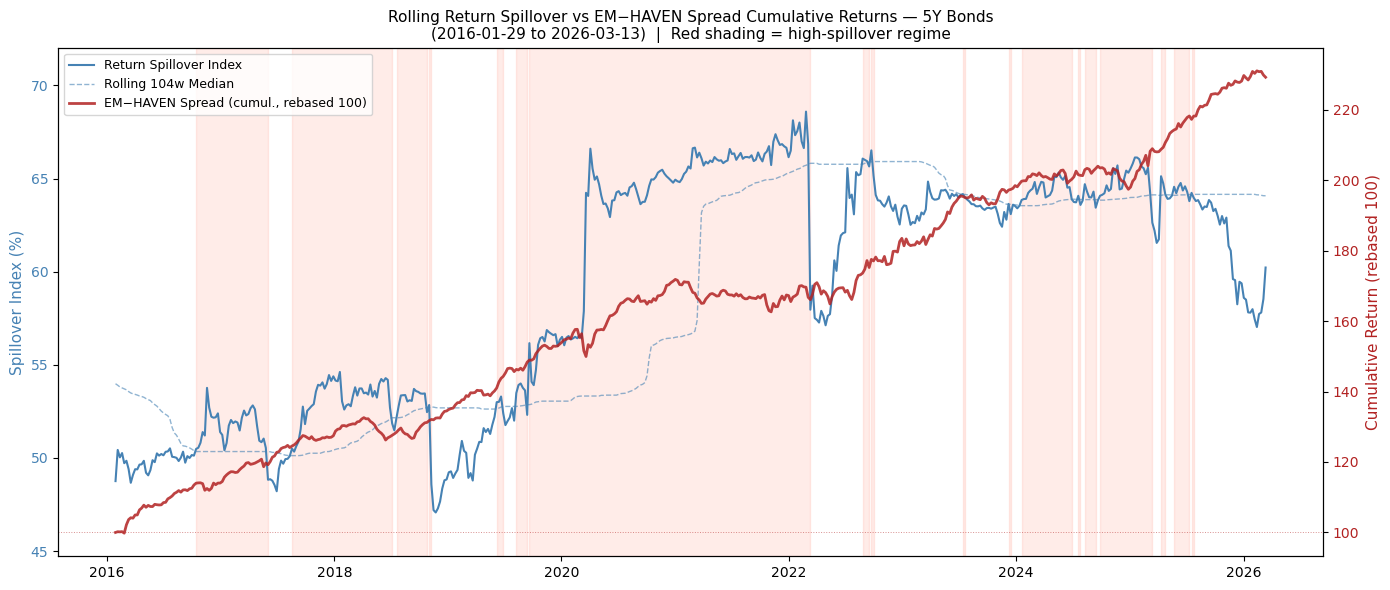

In [55]:
# ── 8d. ROLLING RETURN SPILLOVER vs EM-HAVEN CUMULATIVE RETURNS ───────────────
spill_plot   = spill.loc[split_date:]
roll_med_plot = spill.rolling(REGIME_WINDOW, min_periods=REGIME_WINDOW//2).median().shift(1).loc[split_date:]

cum_spread = (1 + spread_ret.loc[spill_plot.index.min():]).cumprod()
cum_spread = cum_spread / cum_spread.iloc[0] * 100
cum_spread = cum_spread.reindex(spill_plot.index).ffill()

fig, ax1 = plt.subplots(figsize=(14, 6))

# ── left axis: spillover ───────────────────────────────────────────────────────
ax1.plot(spill_plot.index, spill_plot.values, lw=1.5, color='steelblue',
         label='Return Spillover Index', zorder=3)
ax1.plot(roll_med_plot.index, roll_med_plot.values, lw=1, color='steelblue',
         ls='--', alpha=0.6, label=f'Rolling {REGIME_WINDOW}w Median', zorder=3)

# shade high-spillover regions
high_mask_plot = spill_plot >= roll_med_plot
in_high = False
seg_start = None
for date, is_high in high_mask_plot.items():
    if is_high and not in_high:
        seg_start = date
        in_high = True
    elif not is_high and in_high:
        ax1.axvspan(seg_start, date, color='tomato', alpha=0.12, zorder=1)
        in_high = False
if in_high:
    ax1.axvspan(seg_start, spill_plot.index[-1], color='tomato', alpha=0.12, zorder=1)

ax1.set_ylabel('Spillover Index (%)', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(spill_plot.min() * 0.95, spill_plot.max() * 1.05)

# ── right axis: cumulative spread return ──────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(cum_spread.index, cum_spread.values, lw=2, color='firebrick',
         alpha=0.85, label='EM−HAVEN Spread (cumul., rebased 100)', zorder=2)
ax2.set_ylabel('Cumulative Return (rebased 100)', color='firebrick', fontsize=11)
ax2.tick_params(axis='y', labelcolor='firebrick')
ax2.axhline(100, color='firebrick', ls=':', lw=0.7, alpha=0.5)

# ── combined legend ────────────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

ax1.set_title(f'Rolling Return Spillover vs EM−HAVEN Spread Cumulative Returns — {term}Y Bonds\n'
              f'({split_date.date()} to {dates[-1].date()})  |  Red shading = high-spillover regime',
              fontsize=11)
ax1.set_xlabel('')
plt.tight_layout()
plt.show()


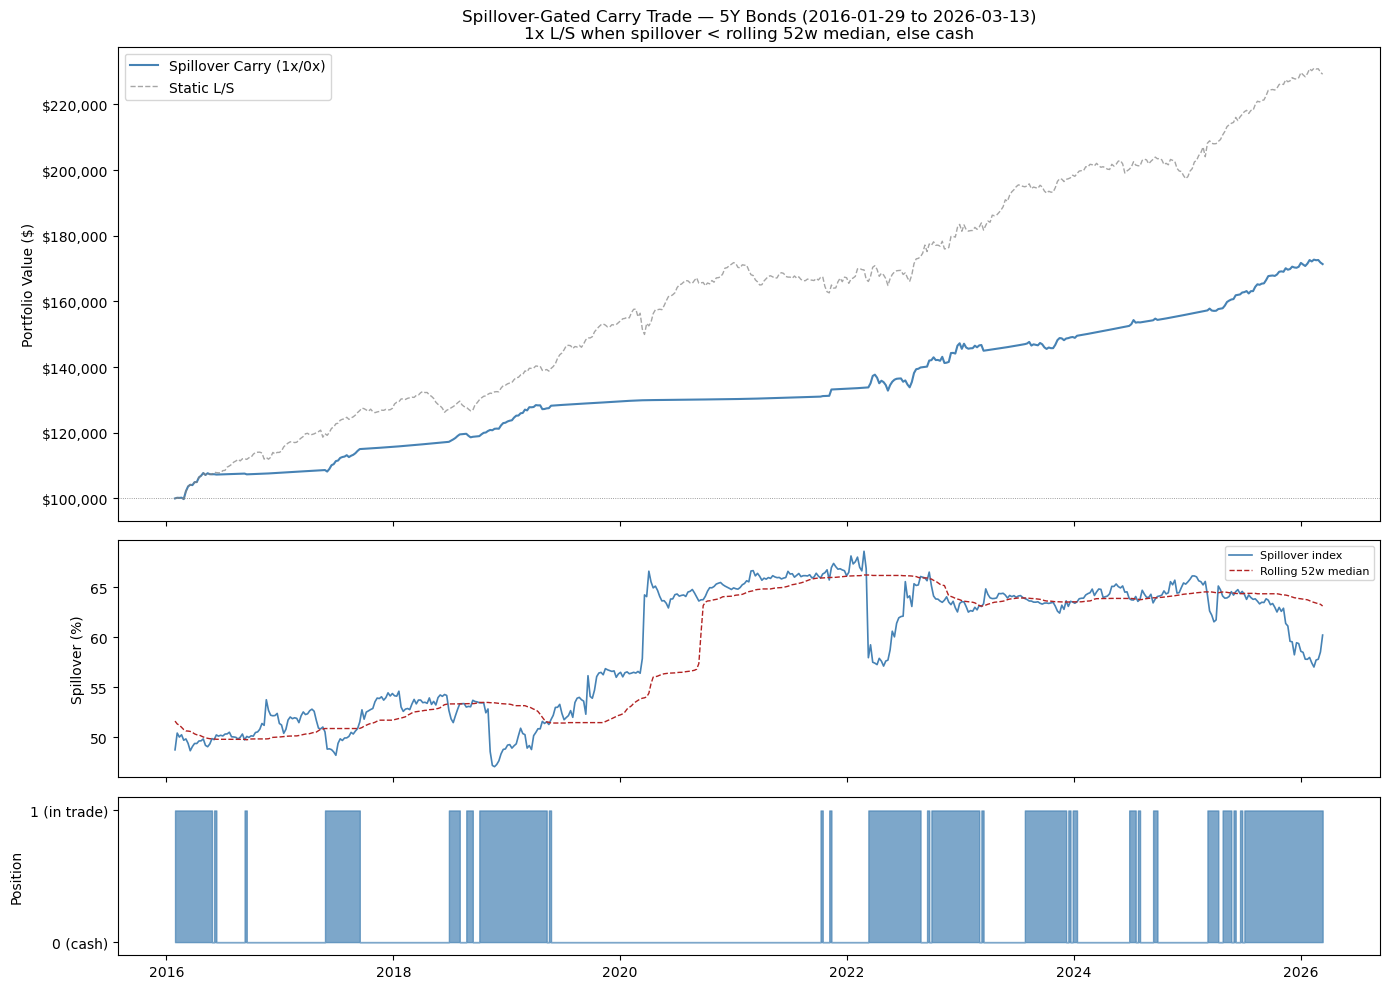

In [51]:
# ── 9. STRATEGY DETAIL PLOT ───────────────────────────────────────────────────
port_oos     = portfolio_rf.loc[split_date:end_date].dropna()
sc_oos       = scalar_ts.reindex(port_oos.index).ffill()
spill_oos    = spill.loc[split_date:end_date]
roll_med_oos = roll_median.loc[split_date:end_date]
oos_ls_plot  = port_ls.loc[split_date:end_date].dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1.5, 1]})

axes[0].plot(port_oos.index, port_oos.values, lw=1.5, color='steelblue',
             label='Spillover Carry (1x/0x)')
axes[0].plot(oos_ls_plot.index, oos_ls_plot.values, lw=1, color='gray',
             ls='--', label='Static L/S', alpha=0.7)
axes[0].axhline(STARTING_CASH, color='gray', ls=':', lw=0.6)
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title(f'Spillover-Gated Carry Trade — {term}Y Bonds ({split_date.date()} to {end_date.date() if END_DATE else dates[-1].date()})\n'
                  f'1x L/S when spillover < rolling {Z_WINDOW}w median, else cash')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

axes[1].plot(spill_oos.index, spill_oos.values, lw=1.2, color='steelblue', label='Spillover index')
axes[1].plot(roll_med_oos.index, roll_med_oos.values, lw=1, color='firebrick',
             ls='--', label=f'Rolling {Z_WINDOW}w median')
axes[1].set_ylabel('Spillover (%)')
axes[1].legend(fontsize=8)

axes[2].fill_between(sc_oos.index, sc_oos.values, step='post', alpha=0.7, color='steelblue')
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_ylabel('Position')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['0 (cash)', '1 (in trade)'])

plt.tight_layout()
plt.show()


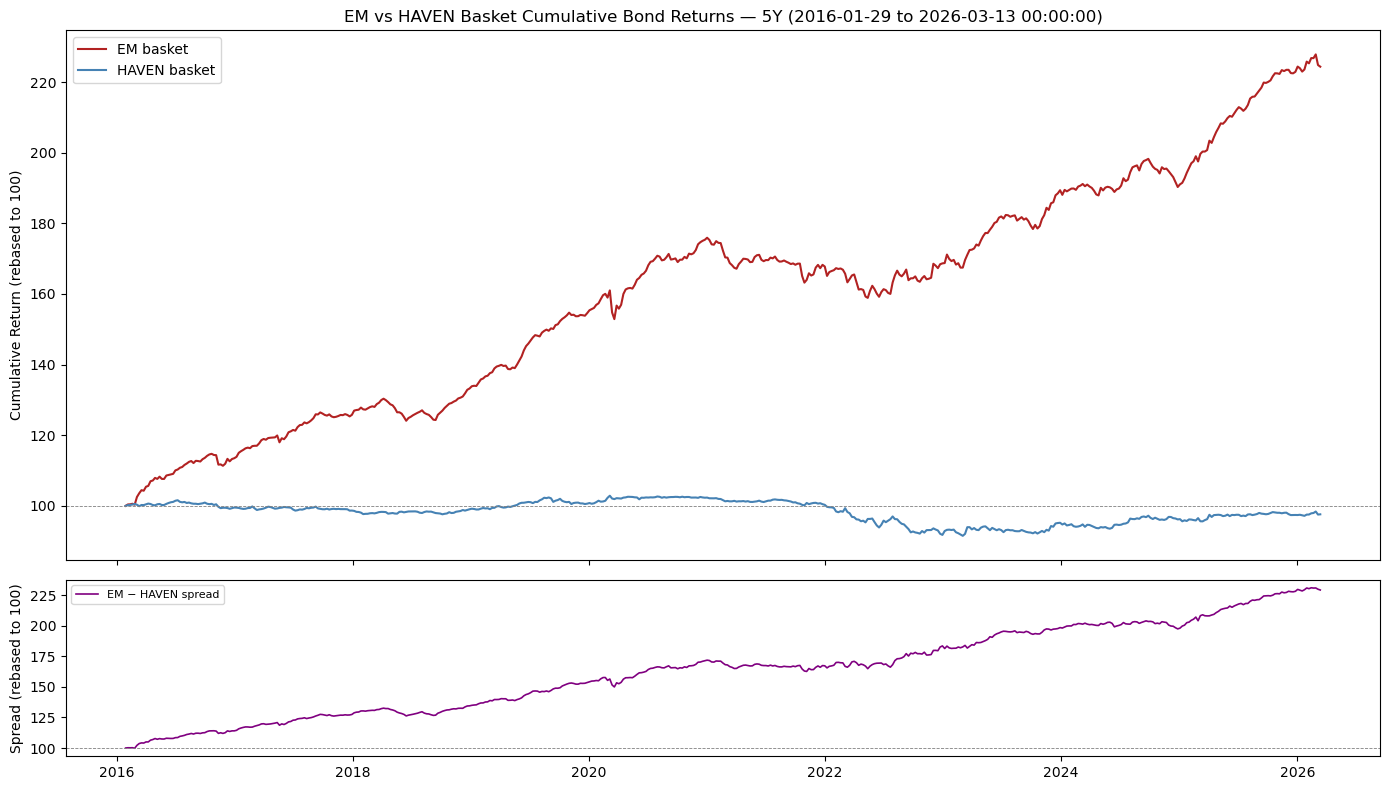

In [52]:
# ── BASKET CUMULATIVE RETURNS: EM vs HAVEN ────────────────────────────────────
em_cum    = (1 + bond_rets[EM_BASKET].mean(axis=1).loc[split_date:end_date]).cumprod()
haven_cum = (1 + bond_rets[HAVEN_BASKET].mean(axis=1).loc[split_date:end_date]).cumprod()

# index to 100 at start
em_cum    = em_cum / em_cum.iloc[0] * 100
haven_cum = haven_cum / haven_cum.iloc[0] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(em_cum.index,    em_cum.values,    lw=1.5, color='firebrick', label='EM basket')
axes[0].plot(haven_cum.index, haven_cum.values, lw=1.5, color='steelblue', label='HAVEN basket')
axes[0].axhline(100, color='gray', ls='--', lw=0.6)
axes[0].set_ylabel('Cumulative Return (rebased to 100)')
axes[0].set_title(f'EM vs HAVEN Basket Cumulative Bond Returns — {term}Y ({split_date.date()} to {end_date or dates[-1].date()})')
axes[0].legend()

# spread return
spread_cum = (1 + spread_ret.loc[split_date:end_date]).cumprod()
spread_cum = spread_cum / spread_cum.iloc[0] * 100
axes[1].plot(spread_cum.index, spread_cum.values, lw=1.2, color='purple', label='EM − HAVEN spread')
axes[1].axhline(100, color='gray', ls='--', lw=0.6)
axes[1].set_ylabel('Spread (rebased to 100)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Sample: full  (n=630 weeks)
LHS: daily-based ann. vol of EM-HAVEN spread (next 5 days)
RHS: spillover z-score (expanding, lagged 1w)

  alpha = 0.0375  (t=+25.79, p=0.000)
  beta  = 0.0026  (t=+2.33, p=0.020)
  R2    = 0.0212
  Ann. avg vol when DY_z > 0: 4.22%
  Ann. avg vol when DY_z < 0: 3.23%


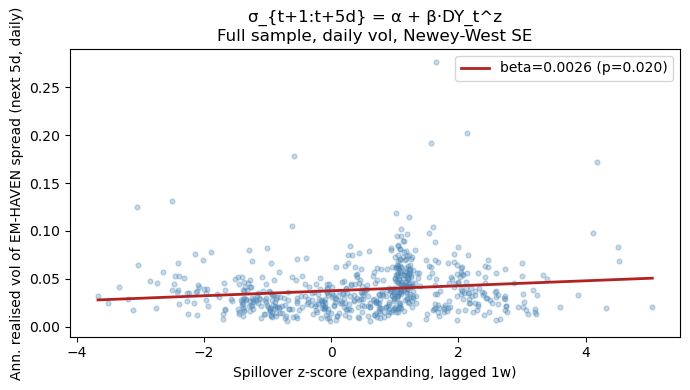

In [53]:
# ── VOLATILITY REGRESSION: σ_{t+1:t+1w} = α + β·DY_t^z ───────────────────────
# Uses daily yields for vol estimation, weekly spillover as predictor
import statsmodels.api as sm

# load daily yields (only for vol computation)
raw_yields_d  = get_yield(term, freq='B') / 100
yield_chg_d   = raw_yields_d.diff().dropna()
carry_d       = raw_yields_d.shift(1).reindex(yield_chg_d.index) / 252
bond_rets_d   = carry_d - term * yield_chg_d
spread_ret_d  = bond_rets_d[EM_BASKET].mean(axis=1) - bond_rets_d[HAVEN_BASKET].mean(axis=1)

# 5-day (1-week) forward realised vol, resampled to weekly (Friday)
fwd_vol_d = (spread_ret_d.rolling(5).std().shift(-5) * np.sqrt(252)).rename('fwd_vol')
fwd_vol_w = fwd_vol_d.resample('W-FRI').last()  # align to weekly spillover dates

# z-scored spillover (expanding, lagged 1 week)
dy_z = ((spill - spill.expanding().mean()) / spill.expanding().std()).shift(1).rename('DY_z')

data = pd.concat([fwd_vol_w, dy_z], axis=1).dropna()
data.columns = ['fwd_vol', 'DY_z']

X = sm.add_constant(data['DY_z'])
y = data['fwd_vol']
res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'Sample: full  (n={len(data)} weeks)')
print(f'LHS: daily-based ann. vol of EM-HAVEN spread (next 5 days)')
print(f'RHS: spillover z-score (expanding, lagged 1w)')
print(f"\n{'='*60}")
print(f'  alpha = {res.params["const"]:.4f}  (t={res.tvalues["const"]:+.2f}, p={res.pvalues["const"]:.3f})')
print(f'  beta  = {res.params["DY_z"]:.4f}  (t={res.tvalues["DY_z"]:+.2f}, p={res.pvalues["DY_z"]:.3f})')
print(f'  R2    = {res.rsquared:.4f}')
print(f'  Ann. avg vol when DY_z > 0: {data.loc[data["DY_z"]>0,"fwd_vol"].mean():.2%}')
print(f'  Ann. avg vol when DY_z < 0: {data.loc[data["DY_z"]<0,"fwd_vol"].mean():.2%}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(data['DY_z'], data['fwd_vol'], alpha=0.3, s=12, color='steelblue')
x_line = np.linspace(data['DY_z'].min(), data['DY_z'].max(), 100)
y_line = res.params['const'] + res.params['DY_z'] * x_line
ax.plot(x_line, y_line, color='firebrick', lw=2,
        label=f'beta={res.params["DY_z"]:.4f} (p={res.pvalues["DY_z"]:.3f})')
ax.set_xlabel('Spillover z-score (expanding, lagged 1w)')
ax.set_ylabel('Ann. realised vol of EM-HAVEN spread (next 5d, daily)')
ax.set_title('σ_{t+1:t+5d} = α + β·DY_t^z\nFull sample, daily vol, Newey-West SE')
ax.legend()
plt.tight_layout()
plt.show()
